# DBSCAN: Density-Based Clustering

            ## 1. Learning objectives

            - Define core, border, and noise points
- Implement density expansion
- Tune neighborhood radius and minimum samples

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Find arbitrarily shaped dense regions while labeling isolated observations as noise.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            A point starts or expands a cluster when enough neighbors fit inside a small radius; sparse points remain unassigned.

## 6. Mathematical foundation

            $$N_{\varepsilon}(\mathbf{x})=\{\mathbf{y}:d(\mathbf{x},\mathbf{y})\leq\varepsilon\}.$$

            **Every symbol:**

            - $\mathbf{x}$ is the current point.
- $\mathbf{y}$ is another observation.
- $d$ is distance.
- $\varepsilon$ is the radius.
- $N_\varepsilon$ is the neighbor set.

            **Why the equation is needed:** Counting this set determines whether a point is a core point.

            **Small numerical example:** If distances are [0, .1, .3, .8] and epsilon=.35, the first three points are neighbors.

            **Connection to Python:** np.flatnonzero(distances <= eps) returns the neighborhood.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def dbscan_scratch(features, eps, min_samples):
    labels = np.full(len(features), -99, dtype=int)
    distances = np.linalg.norm(features[:, None, :] - features[None, :, :], axis=2)
    neighbors = [np.flatnonzero(distances[index] <= eps) for index in range(len(features))]
    cluster_id = 0
    for point in range(len(features)):
        if labels[point] != -99:
            continue
        if len(neighbors[point]) < min_samples:
            labels[point] = -1
            continue
        labels[point] = cluster_id
        seeds = list(map(int, neighbors[point]))
        cursor = 0
        while cursor < len(seeds):
            candidate = seeds[cursor]
            if labels[candidate] == -1:
                labels[candidate] = cluster_id
            if labels[candidate] == -99:
                labels[candidate] = cluster_id
                if len(neighbors[candidate]) >= min_samples:
                    seeds.extend(int(value) for value in neighbors[candidate] if int(value) not in seeds)
            cursor += 1
        cluster_id += 1
    labels[labels == -99] = -1
    return labels

print("Scratch DBSCAN defined; -1 is the noise label.")

Scratch DBSCAN defined; -1 is the noise label.


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Scratch/library ARI: 1.0
Clusters: 2 noise: 1
Non-noise silhouette: 0.376


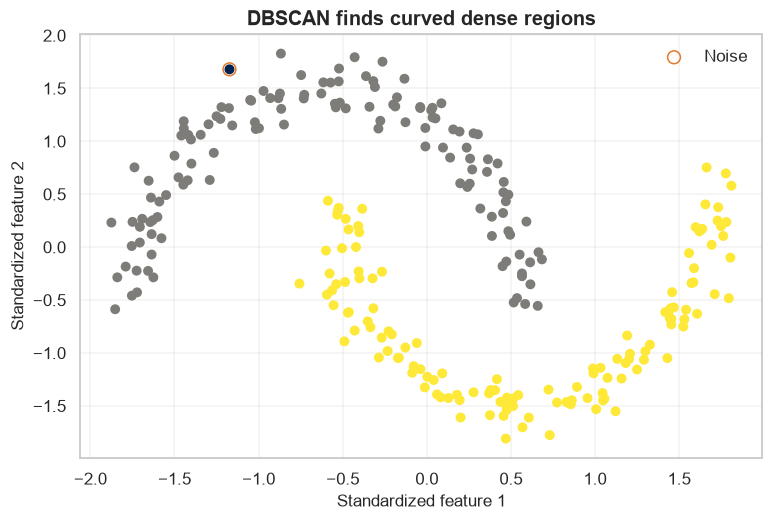

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X, hidden_labels = make_moons(n_samples=260, noise=.07, random_state=RANDOM_SEED)
X_scaled = StandardScaler().fit_transform(X)
scratch_labels = dbscan_scratch(X_scaled, eps=.25, min_samples=5)
library_labels = DBSCAN(eps=.25, min_samples=5).fit_predict(X_scaled)
cluster_mask = library_labels != -1
print("Scratch/library ARI:", round(adjusted_rand_score(scratch_labels, library_labels), 3))
print("Clusters:", len(set(library_labels)) - (-1 in library_labels), "noise:", int((library_labels == -1).sum()))
print("Non-noise silhouette:", round(silhouette_score(X_scaled[cluster_mask], library_labels[cluster_mask]), 3))

figure, axis = plt.subplots()
axis.scatter(X_scaled[:, 0], X_scaled[:, 1], c=library_labels, cmap="cividis", s=30)
axis.scatter(X_scaled[~cluster_mask, 0], X_scaled[~cluster_mask, 1], facecolors="none", edgecolors=COURSE_COLORS["orange"], s=70, label="Noise")
axis.set(title="DBSCAN finds curved dense regions", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
axis.legend()
plt.show()

**How to interpret the result:** DBSCAN follows the two-moons geometry without requiring a cluster count; outlined observations are noise.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Smaller epsilon marks more points as noise; larger epsilon can merge distinct dense regions.

,eps,clusters,noise_points
0,0.15,13,62
1,0.20,6,7
2,0.25,2,1
3,0.30,2,0
4,0.40,2,0


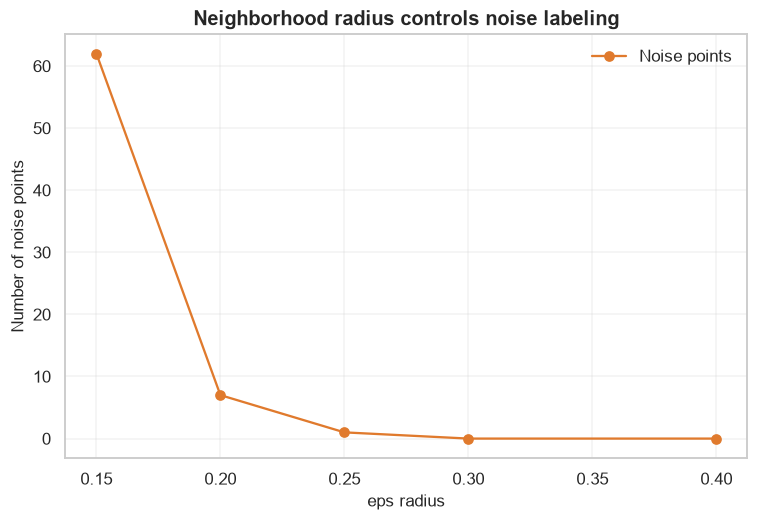

In [4]:
rows = []
for eps in [.15, .20, .25, .30, .40]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    rows.append({"eps": eps, "clusters": len(set(labels)) - (-1 in labels), "noise_points": int((labels == -1).sum())})
results = pd.DataFrame(rows)
display(results)
figure, axis = plt.subplots()
axis.plot(results["eps"], results["noise_points"], marker="o", color=COURSE_COLORS["orange"], label="Noise points")
axis.set(title="Neighborhood radius controls noise labeling", xlabel="eps radius", ylabel="Number of noise points")
axis.legend()
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Finds non-spherical shapes
- Identifies noise explicitly
- Does not require a cluster count

            **Disadvantages**

            - Sensitive to scaling and density variation
- Neighborhood searches are difficult in high dimensions

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can cluster labels 0 and 1 not be interpreted as low and high?
2. **Mathematical/hand calculation:** Compute the Euclidean distance between (0, 0) and (3, 4).
3. **Coding/experimentation:** Change the random seed and check whether the structure is stable.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Cluster IDs are arbitrary names; permuting them does not change the grouping.
2. $\sqrt{3^2+4^2}=5$.
3. Rerun with several seeds and compare scores plus assignments; instability is evidence that conclusions need caution.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html)